$$PARTE \quad 1D $$

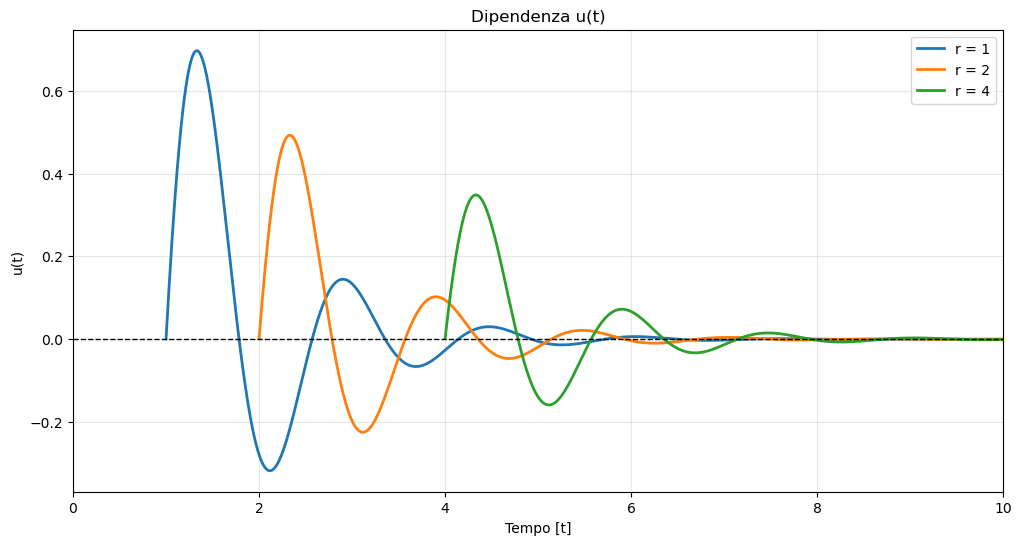

In [42]:
import numpy as np
import matplotlib.pyplot as plt

r_lista = [1, 2, 4]
t_punti = np.linspace(0, 10, 5000)

plt.figure(figsize=(12,6))

for r in r_lista:
    
    t_validi = []  ##per non avere le linee a 0 
    u_validi = []
    
    for t in t_punti:
        tau = t - r
        if tau >= 0:
            valore_u = np.exp(-tau) * np.sin(4 * tau) / np.sqrt(r)
            t_validi.append(t)
            u_validi.append(valore_u)
    
    #plot dei _validi
    plt.plot(t_validi, u_validi, label=f"r = {r}", lw=2)

plt.title("Dipendenza u(t)")
plt.xlabel("Tempo [t]")
plt.ylabel("u(t)")
plt.axhline(0, color='black', lw=1, ls="--")
plt.xlim(0, 10) 
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
    

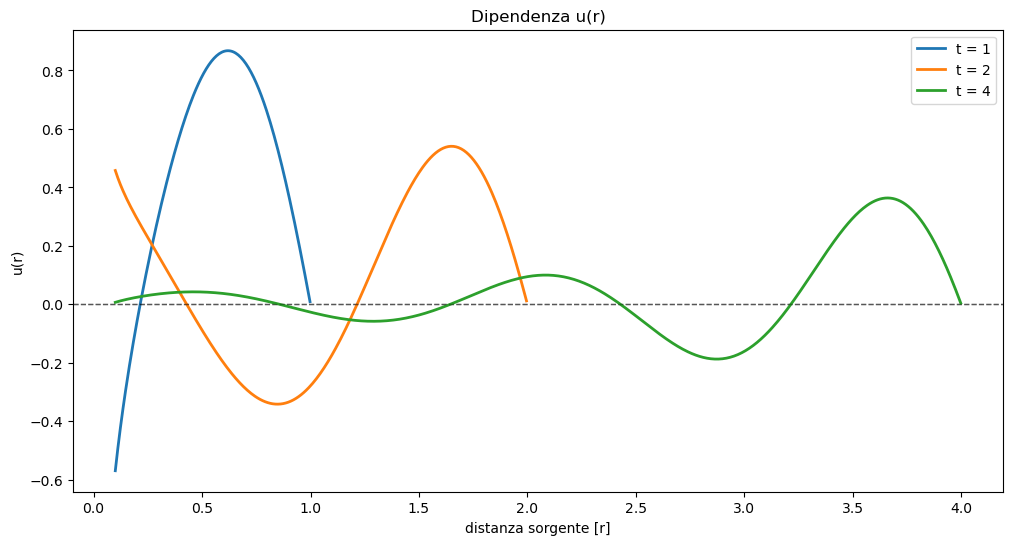

In [61]:
import numpy as np
import matplotlib.pyplot as plt

t_lista = [1, 2, 4]
r_punti = np.linspace(0.1, 6, 1000)

plt.figure(figsize=(12, 6))

for t in t_lista:
    
    r_validi = []  ##per non avere le linee a 0 
    u_validi = []
    
    for r in r_punti:
        tau = t - r
        if tau >= 0:
            u = np.exp(-tau) * np.sin(4 * tau) / np.sqrt(r)
            r_validi.append(r)
            u_validi.append(u)
    
    #plot dei _validi
    plt.plot(r_validi, u_validi, label=f"t = {t}", lw=2)
    plt.title("Dipendenza u(r)")
    plt.ylabel("u(r)")
    plt.xlabel("distanza sorgente [r]")
    plt.axhline(0, color='black', lw=1, ls="--", alpha=0.3)
    plt.legend()

$$ PARTE \quad 2D $$



In [15]:
import numpy as np
import matplotlib.pyplot as plt
##step 1##
L = 12
N = 250

x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)

X,Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)
##step 2##
def calcolo_u (t, R, v=1):
    tau = t - R/v
    mask = (tau >=0 )
    u = np.where(mask, np.exp(-tau) * np.sin(4 * tau) / np.sqrt(R + 1e-10), 0.0) #aggiungo un piccolo valore a R per non far dividere per 0
    return u                                                                     #la condizione true della mask è tau >= 0
##step 3##
"""t_scelto = 4
u = calcolo_u(t_scelto, R)
plt.figure(figsize=(10,10))
plt.imshow(u, extent=[-L/2, L/2, -L/2, L/2],origin='lower', cmap='RdBu', vmin=-1, vmax=1)
plt.title(f"Istante t = {t_scelto}")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig('frame_000.png', dpi=80, bbox_inches='tight')
plt.close()"""
##step 4 generazione frame##
nframe = 200
dt = 0.05
for i in range (nframe):
    t_adesso = i * dt
    u = calcolo_u(t_adesso, R)
    plt.figure(figsize=(10,10))
    plt.imshow(u, extent=[-L/2, L/2, -L/2, L/2],origin='lower', cmap='RdBu', vmin=-1, vmax=1)
    plt.title(f"Istante t = {t_adesso:.2f}")
    ##salvataggio file##
    nome = f"frame{i:03d}.png"
    plt.savefig(nome, dpi = 80, bbox_inches="tight")
    plt.close()
print("finito tutto <3")


finito tutto <3


$$ INTERFERENZA $$


In [21]:
import numpy as np
import matplotlib.pyplot as plt

L = 12
N = 250

x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)

X,Y = np.meshgrid(x, y)

R1 = np.sqrt(X**2 + (Y-2)**2)  ##distanze per le due onde
R2 = np.sqrt(X**2 + (Y+2)**2)

def calcolo_u (t, R, v=1):  ##stessa funzione di prima la uso per onda2
    tau = t - R/v
    mask = (tau >=0 )
    u = np.where(mask, np.exp(-tau) * np.sin(4 * tau) / np.sqrt(R + 1e-10), 0.0) #aggiungo un piccolo valore a R per non far dividere per 0
    return u

def onda_due (t, R1, R2):
    u1 = calcolo_u(t, R1)
    u2 = calcolo_u(t, R2)
    return u1 + u2

##generazione immagini praticamente uguale a prima#
nframe = 200
dt = 0.05
for i in range(nframe):
    t_adesso = i * dt
    
    # Usiamo la nuova funzione con le due sorgenti
    u_totale = onda_due(t_adesso, R1, R2)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(u_totale, 
               extent=[-L/2, L/2, -L/2, L/2], origin='lower', cmap='RdBu', vmin=-2, vmax=2)  
    ##ho cambiato i vmax e min perchè i picchi potrebbero superare 1?#
    plt.title(f"Interferenza a t = {t_adesso:.2f}")
    plt.savefig(f"interf{i:03d}.png", dpi=80, bbox_inches='tight')
    plt.close()
print("finito tutto 2")



finito tutto 2
